# Decoder-Only Reconstruction Evaluation

Systematic evaluation of decoder-only reconstruction from FM embeddings.

**Panels:**
1. FM model comparison (MLP decoder, 4 FMs, 3 splits × 5 seeds)
2. Decoder architecture comparison (MLP vs Transformer vs KNN, aggregated across FMs)
3. Funky heatmap: FM × metrics (MLP decoder)
4. Funky heatmap: Decoder arch × metrics (aggregated across FMs)

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
import pickle
warnings.filterwarnings('ignore')

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11,
    'axes.titlesize': 12,
})

## 1. Config & Data Loading

In [2]:
MODELS = ["SE", "scGPT", "scConcept", "scimilarity"]
SPLITS = ["split01", "split02", "split03"]
SEEDS = [42, 43, 44, 45, 46]

DECODER_CONFIGS = {
    "MLP": None,
    "KNN_10": "KNN_10",
    "Transformer": "500_TF128_H8_L6_*",
}

METRIC_DEFS = [
    ("distributional", "r2_score", None, "R\u00b2", True),
    ("distributional", "mse", None, "MSE", False),
    ("distributional", "energy_distance", None, "Energy dist", False),
    ("pathway", "average", "spearman", "Pathway", True),
    ("coexpression", "average", "spearman", "Coexpression", True),
    ("cellcycle", "proportion_same_phase", None, "Cell cycle", True),
    ("cytokine", "average", "spearman", "Cytokine", True),
    ("deg", "pred_deg_dice_100", "wilcoxon", "DEG dice@100", True),
    ("deg", "pred_mean_genediff_spearman", "wilcoxon", "LogFC Sp.", True),
]

MODEL_COLORS = {
    "SE":          "#4daf8b",   # soft green
    "scGPT":       "#d4756a",   # salmon
    "scConcept":   "#8d87bf",   # soft violet
    "scimilarity": "#d4b35a",   # warm sand
}

DECODER_COLORS = {
    "MLP": "#6baed6",        # soft blue
    "KNN_10": "#d4956a",     # muted peach
    "Transformer": "#8fbc8f", # sage green
}

DIST_METRICS = {"R\u00b2", "MSE", "Energy dist"}
BIO_METRICS = {"Pathway", "Coexpression", "Cell cycle", "DEG dice@100", "LogFC Sp.", "Cytokine"}

MODEL_LABELS = {
    "SE":          "SE-2058",
    "scConcept":   "scConcept-512",
    "scGPT":       "scGPT-512",
    "scimilarity": "SCimilarity-128",
}
DECODER_LABELS = {
    "MLP":         "MLP",
    "KNN_10":      "KNN",
    "Transformer": "Transformer",
}

FM_DISPLAY = {"SE": "SE", "scGPT": "scGPT", "scConcept": "scConcept", "scimilarity": "SCimilarity"}

df_all = pd.read_csv("../frozen/figs/decoder_only.csv")

## 2. Rank-Percentile Score Computation

In [3]:
def rank_percentile(s):
    """Paper formula: rp = (M - rank) / (M - 1), where rank 1 = best.

    Caller must orient `s` so that higher value = better (negate
    lower-is-better metrics upstream — see compute_scores_per_replicate).
    Range = [0, 1]; best method gets 1.0, worst gets 0.0.
    """
    s = s.astype(float)
    valid = s.dropna()
    if valid.nunique() <= 1 or len(valid) < 2:
        return pd.Series(np.nan, index=s.index)
    M = len(valid)
    ranks = s.rank(method="average", ascending=False)
    return (M - ranks) / (M - 1)


def _rp_paper(vals, higher_is_better):
    """Paper rank-percentile applied directly to one metric column.

    Used by the funky-heatmap cells where direction is handled per column.
    higher_is_better=True  → best is highest value
    higher_is_better=False → best is lowest value (rank 1 = lowest)
    """
    vals = pd.Series(vals).astype(float)
    M = vals.notna().sum()
    if M < 2 or vals.dropna().nunique() <= 1:
        return pd.Series(np.nan, index=vals.index)
    ranks = vals.rank(method="average", ascending=(not higher_is_better))
    return (M - ranks) / (M - 1)


def bootstrap_ci(values, n_boot=4000, alpha=0.05, seed=42):
    """Bootstrap 95% CI for the mean."""
    rng = np.random.default_rng(seed)
    values = np.array(values, dtype=float)
    values = values[~np.isnan(values)]
    if len(values) == 0:
        return np.nan, np.nan, np.nan
    if len(values) == 1:
        v = float(values[0]); return v, v, v
    boots = [np.mean(rng.choice(values, size=len(values), replace=True)) for _ in range(n_boot)]
    boots = np.array(boots)
    return float(np.mean(values)), float(np.quantile(boots, alpha/2)), float(np.quantile(boots, 1-alpha/2))


def compute_scores_per_replicate(df_all, group_cols):
    """
    For each (split, seed), rank all entries on each metric,
    then average rank-percentiles into dist/bio/overall scores.
    Returns one row per (group_key, split, seed) = one replicate.
    """
    sub = df_all.dropna(subset=["mean"]).copy()
    sub["group_key"] = sub[group_cols].astype(str).agg("_".join, axis=1)
    
    all_scores = []
    for (split, metric), grp in sub.groupby(["split", "metric"]):
        hib = grp["higher_better"].iloc[0]
        vals = grp["mean"].copy()
        if not hib:
            vals = -vals
        grp = grp.copy()
        grp["rank_pct"] = rank_percentile(vals)
        all_scores.append(grp)
    
    if not all_scores:
        return pd.DataFrame()
    ranked = pd.concat(all_scores)
    
    reps = []
    for (key, split), grp in ranked.groupby(["group_key", "split"]):
        row_info = grp.iloc[0][group_cols].to_dict()
        dist_pct = grp[grp["metric"].isin(DIST_METRICS)]["rank_pct"]
        bio_pct = grp[grp["metric"].isin(BIO_METRICS)]["rank_pct"]
        d = dist_pct.mean() if len(dist_pct) > 0 else np.nan
        b = bio_pct.mean() if len(bio_pct) > 0 else np.nan
        o = 0.5 * (d + b) if np.isfinite(d) and np.isfinite(b) else np.nan
        reps.append({**row_info, "split": split,
                     "score_distributional": d, "score_biological": b, "score_overall": o})
        for metric in grp["metric"].unique():
            reps[-1][f"score_{metric}"] = grp[grp["metric"] == metric]["rank_pct"].mean()
    
    return pd.DataFrame(reps)


def make_agg_df(score_df, group_cols):
    """Bootstrap CI across replicates (splits) for each group."""
    agg = []
    for key_vals, grp in score_df.groupby(group_cols, sort=False):
        if isinstance(key_vals, str):
            key_vals = [key_vals]
        key_dict = dict(zip(group_cols, key_vals))
        for score_name in ["score_overall", "score_distributional", "score_biological"]:
            mean, lo, hi = bootstrap_ci(grp[score_name].to_numpy())
            agg.append({**key_dict, "score": score_name, "mean": mean, "lo": lo, "hi": hi})
    return pd.DataFrame(agg)

## 3. Panel A — FM Comparison (MLP Decoder)

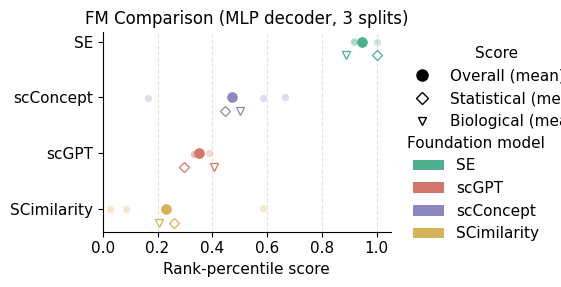

In [4]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

df_mlp = df_all[df_all["decoder"] == "MLP"].copy()
score_mlp = compute_scores_per_replicate(df_mlp, group_cols=["model"])
agg_mlp = make_agg_df(score_mlp, group_cols=["model"])

order_df = agg_mlp[agg_mlp["score"] == "score_overall"].sort_values("mean", ascending=False)
model_order = order_df["model"].tolist()

marker_dist = "D"   # diamond
marker_bio = "v"    # triangle
y_sub = 0.24
ms_sub = 5.5
mew_sub = 0.9

fig, ax = plt.subplots(figsize=(8, 3))
ypos = np.arange(len(model_order)).astype(float)

rng = np.random.default_rng(0)
for i, model in enumerate(model_order):
    reps = score_mlp[score_mlp["model"] == model]
    col = MODEL_COLORS[model]
    xs = reps["score_overall"].to_numpy(dtype=float)
    jitter = rng.normal(0, 0.015, size=len(xs))
    ax.scatter(xs, np.full_like(xs, ypos[i]) + jitter, s=28, color=col, alpha=0.28, linewidths=0, zorder=1)

for i, model in enumerate(model_order):
    col = MODEL_COLORS[model]

    row_o = agg_mlp[(agg_mlp["model"] == model) & (agg_mlp["score"] == "score_overall")]
    if not row_o.empty:
        mean, lo, hi = float(row_o["mean"].iloc[0]), float(row_o["lo"].iloc[0]), float(row_o["hi"].iloc[0])
        ax.plot(mean, ypos[i], "o", ms=7, color=col, mec=col, mew=0.6, zorder=6)

    row_d = agg_mlp[(agg_mlp["model"] == model) & (agg_mlp["score"] == "score_distributional")]
    if not row_d.empty:
        ax.plot(float(row_d["mean"].iloc[0]), ypos[i] + y_sub, marker=marker_dist, ms=ms_sub,
                mfc="white", mec=col, mew=mew_sub, ls="None", zorder=7)

    row_b = agg_mlp[(agg_mlp["model"] == model) & (agg_mlp["score"] == "score_biological")]
    if not row_b.empty:
        ax.plot(float(row_b["mean"].iloc[0]), ypos[i] + y_sub, marker=marker_bio, ms=ms_sub,
                mfc="white", mec=col, mew=mew_sub, ls="None", zorder=7)

ax.set_yticks(ypos)
ax.set_yticklabels([FM_DISPLAY.get(m, m) for m in model_order])
ax.invert_yaxis()
ax.set_xlim(0, 1.05)
ax.set_xlabel("Rank-percentile score")
ax.xaxis.grid(True, ls="--", alpha=0.35)
ax.set_axisbelow(True)
for spine in ["top", "right"]: ax.spines[spine].set_visible(False)

fig.subplots_adjust(right=0.72)
score_handles = [
    Line2D([0],[0], marker="o", color="black", ls="None", ms=8, label="Overall (mean)"),
    Line2D([0],[0], marker=marker_dist, color="black", ls="None", mfc="white", mew=1.0, ms=6, label="Statistical (mean)"),
    Line2D([0],[0], marker=marker_bio, color="black", ls="None", mfc="white", mew=1.0, ms=6, label="Biological (mean)"),
]
leg1 = ax.legend(handles=score_handles, title="Score", loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False)
fm_handles = [Patch(facecolor=MODEL_COLORS[m], edgecolor="none", label=FM_DISPLAY.get(m, m)) for m in MODELS]
leg2 = ax.legend(handles=fm_handles, title="Foundation model", loc="upper left", bbox_to_anchor=(1.01, 0.55), frameon=False)
ax.add_artist(leg1)
ax.set_title("FM Comparison (MLP decoder, 3 splits)")
plt.tight_layout(rect=[0, 0, 0.72, 1])
OUT_SVG = "../figs/fig3/decoder_fm_comparison.svg"
fig.savefig(OUT_SVG, format="svg", bbox_inches="tight", bbox_extra_artists=[leg1, leg2])

plt.show()

## 4. Panel B — Decoder Architecture Comparison

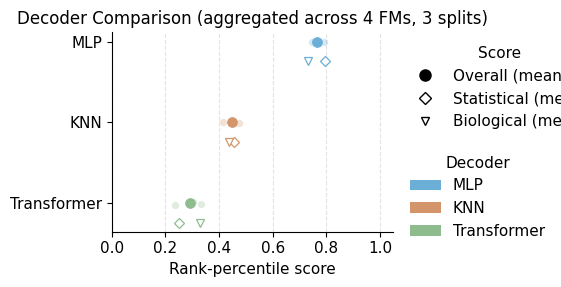

In [5]:
score_dec = compute_scores_per_replicate(df_all, group_cols=["decoder"])
agg_dec = make_agg_df(score_dec, group_cols=["decoder"])

order_df = agg_dec[agg_dec["score"] == "score_overall"].sort_values("mean", ascending=False)
dec_order = order_df["decoder"].tolist()

fig, ax = plt.subplots(figsize=(8, 3))
ypos = np.arange(len(dec_order)).astype(float)

rng = np.random.default_rng(0)
for i, dec in enumerate(dec_order):
    reps = score_dec[score_dec["decoder"] == dec]
    col = DECODER_COLORS.get(dec, "gray")
    xs = reps["score_overall"].to_numpy(dtype=float)
    jitter = rng.normal(0, 0.015, size=len(xs))
    ax.scatter(xs, np.full_like(xs, ypos[i]) + jitter, s=28, color=col, alpha=0.28, linewidths=0, zorder=1)

for i, dec in enumerate(dec_order):
    col = DECODER_COLORS.get(dec, "gray")
    row_o = agg_dec[(agg_dec["decoder"] == dec) & (agg_dec["score"] == "score_overall")]
    if not row_o.empty:
        mean, lo, hi = float(row_o["mean"].iloc[0]), float(row_o["lo"].iloc[0]), float(row_o["hi"].iloc[0])
        ax.plot(mean, ypos[i], "o", ms=7, color=col, mec=col, mew=0.6, zorder=6)
    row_d = agg_dec[(agg_dec["decoder"] == dec) & (agg_dec["score"] == "score_distributional")]
    if not row_d.empty:
        ax.plot(float(row_d["mean"].iloc[0]), ypos[i] + 0.24, marker="D", ms=5.5,
                mfc="white", mec=col, mew=0.9, ls="None", zorder=7)
    row_b = agg_dec[(agg_dec["decoder"] == dec) & (agg_dec["score"] == "score_biological")]
    if not row_b.empty:
        ax.plot(float(row_b["mean"].iloc[0]), ypos[i] + 0.24, marker="v", ms=5.5,
                mfc="white", mec=col, mew=0.9, ls="None", zorder=7)

ax.set_yticks(ypos)
ax.set_yticklabels([DECODER_LABELS.get(d, d) for d in dec_order])
ax.invert_yaxis()
ax.set_xlim(0, 1.05)
ax.set_xlabel("Rank-percentile score")
ax.xaxis.grid(True, ls="--", alpha=0.35)
ax.set_axisbelow(True)
for spine in ["top", "right"]: ax.spines[spine].set_visible(False)

fig.subplots_adjust(right=0.72)
score_handles = [
    Line2D([0],[0], marker="o", color="black", ls="None", ms=8, label="Overall (mean)"),
    Line2D([0],[0], marker="D", color="black", ls="None", mfc="white", mew=1.0, ms=6, label="Statistical (mean)"),
    Line2D([0],[0], marker="v", color="black", ls="None", mfc="white", mew=1.0, ms=6, label="Biological (mean)"),
]
leg1 = ax.legend(handles=score_handles, title="Score", loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False)
dec_handles = [Patch(facecolor=DECODER_COLORS[d], edgecolor="none", label=DECODER_LABELS.get(d, d)) for d in DECODER_CONFIGS]
leg2 = ax.legend(handles=dec_handles, title="Decoder", loc="upper left", bbox_to_anchor=(1.01, 0.45), frameon=False)
ax.add_artist(leg1)
ax.set_title("Decoder Comparison (aggregated across 4 FMs, 3 splits)")
plt.tight_layout(rect=[0, 0, 0.72, 1])
OUT_SVG = "../figs/fig3/decoder_decoder_comparison.svg"
fig.savefig(OUT_SVG, format="svg", bbox_inches="tight", bbox_extra_artists=[leg1, leg2])

plt.show()

## 5. Panel C — Funky Heatmap: FM × Metrics (MLP Decoder)

Uses `utils.py` from inspectresults to load and merge metric CSVs,
then builds a funky circle heatmap with:
- Rank bars for overall/distributional/biological
- Circles sized by actual metric values (scaled relative to arbitrary baseline)
- Numbers annotated inside circles

In [6]:
baseline_means = dict()
print("PCA_10 baseline (floor for circle scaling):")
for k, v in baseline_means.items():
    print(f"  {k}: {v:.4f}")

PCA_10 baseline (floor for circle scaling):


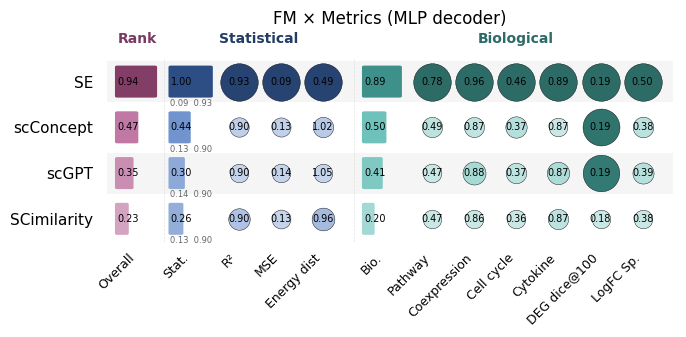

In [7]:
from matplotlib.patches import FancyBboxPatch, Rectangle
import colorsys

df_mlp = df_all[df_all["decoder"] == "MLP"].copy()

metric_labels = [m[3] for m in METRIC_DEFS]
fm_vals = df_mlp.groupby(["model", "metric"])["mean"].mean().unstack()
fm_vals = fm_vals[[m for m in metric_labels if m in fm_vals.columns]]

higher_map = {m[3]: m[4] for m in METRIC_DEFS}
rank_pcts = pd.DataFrame(index=fm_vals.index)
for col in fm_vals.columns:
    vals = fm_vals[col]
    rank_pcts[col] = _rp_paper(vals, higher_map.get(col, True))

stat_labels = [m[3] for m in METRIC_DEFS if m[3] in DIST_METRICS and m[3] in fm_vals.columns]
bio_labels = [m[3] for m in METRIC_DEFS if m[3] in BIO_METRICS and m[3] in fm_vals.columns]

hh_fm = (compute_scores_per_replicate(df_mlp, group_cols=["model"])
         .groupby("model")[["score_overall", "score_distributional", "score_biological"]].mean())
rank_pcts["stat_rank"]    = hh_fm["score_distributional"]
rank_pcts["bio_rank"]     = hh_fm["score_biological"]
rank_pcts["overall_rank"] = hh_fm["score_overall"]

model_order = rank_pcts.sort_values("overall_rank", ascending=False).index.tolist()

col_entries = []
col_entries.append(("Overall", "rank_bar", "overall_rank", "Overall"))
col_entries.append(("Stat.", "rank_bar", "stat_rank", "Stat."))
for m in stat_labels:
    col_entries.append((m, "metric_circle", m, "Stat."))
col_entries.append(("Bio.", "rank_bar", "bio_rank", "Bio."))
for m in bio_labels:
    col_entries.append((m, "metric_circle", m, "Bio."))

col_x = []
x = 0.0
spacing = 0.55
gap_small = 0.08
gap_large = 0.25
for i, (name, ctype, key, group) in enumerate(col_entries):
    if i == 1:
        x += 0.15
    elif i == 2:
        x += gap_small
    elif ctype == "rank_bar" and key == "bio_rank":
        x += gap_large
    elif i > 0 and col_entries[i-1][1] == "rank_bar" and col_entries[i-1][3] == "Bio.":
        x += gap_small
    col_x.append(x)
    x += spacing

col_x = np.array(col_x)
n_models = len(model_order)
RANK_COLORS = {"Overall": "#7A3A61", "Stat.": "#233C66", "Bio.": "#2D6B66"}

def hex_to_hls(h):
    h = h.lstrip("#")
    r, g, b = int(h[0:2],16)/255, int(h[2:4],16)/255, int(h[4:6],16)/255
    return colorsys.rgb_to_hls(r, g, b)

def hls_to_hex(h, l, s):
    r, g, b = colorsys.hls_to_rgb(h, max(0,min(1,l)), max(0,min(1,s)))
    return "#{:02x}{:02x}{:02x}".format(int(r*255), int(g*255), int(b*255))

fig, ax = plt.subplots(figsize=(7, 3.5))

for i in range(n_models):
    if i % 2 == 0:
        ax.add_patch(Rectangle(
            (col_x[0] - 0.40, i - 0.45), col_x[-1] - col_x[0] + 0.80, 0.9,
            fc="#f5f5f5", ec="none", zorder=0
        ))

for i, model in enumerate(model_order):
    y = i
    for j, (name, ctype, key, group) in enumerate(col_entries):
        if ctype == "rank_bar":
            val = rank_pcts.loc[model, key]
            cell_left = col_x[j] - 0.26
            bar_w = val * 0.52
            rc = RANK_COLORS[group]
            hh, ll, ss = hex_to_hls(rc)
            bar_color = hls_to_hex(hh, 0.35 + 0.5*(1-val), ss)
            rect = FancyBboxPatch(
                (cell_left, y - 0.32), bar_w, 0.64,
                boxstyle="round,pad=0.03", fc=bar_color, ec="none", zorder=2
            )
            ax.add_patch(rect)
            ax.text(cell_left , y, f"{val:.2f}",
                    ha="left", va="center", fontsize=7, color="black", zorder=3)


            if key == "stat_rank":
                mse_val = fm_vals.loc[model, "MSE"] if "MSE" in fm_vals.columns else np.nan
                r2_val = fm_vals.loc[model, "R\u00b2"] if "R\u00b2" in fm_vals.columns else np.nan
                if np.isfinite(mse_val) and np.isfinite(r2_val):
                    ax.text(col_x[j], y + 0.38, f"{mse_val:.2f}  {r2_val:.2f}",
                            ha="center", va="top", fontsize=6, color="0.4", zorder=3)

        elif ctype == "metric_circle":
            val = fm_vals.loc[model, key]
            if np.isnan(val):
                continue
            hib = higher_map.get(key, True)
            col_vals = fm_vals[key]
            bl_val = baseline_means.get(key, np.nan)
            if hib:
                vmin = bl_val if np.isfinite(bl_val) else col_vals.min()
                vmax = col_vals.max()
                score = np.clip((val - vmin) / (vmax - vmin), 0, 1) if vmax > vmin else 0.5
            else:
                vmax = bl_val if np.isfinite(bl_val) else col_vals.max()
                vmin = col_vals.min()
                score = np.clip((vmax - val) / (vmax - vmin), 0, 1) if vmax > vmin else 0.5

            base_c = RANK_COLORS[group]
            hh, ll, ss = hex_to_hls(base_c)
            circle_color = hls_to_hex(hh, 0.85 - 0.55*score, ss)

            size = score * 550 + 180
            ax.scatter(col_x[j], y, s=size, c=circle_color, edgecolors="black", linewidths=0.3, zorder=3)
            ax.text(col_x[j], y, f"{val:.2f}", ha="center", va="center", fontsize=7,
                    color="black", zorder=4)

col_names = [e[0] for e in col_entries]
ax.set_yticks(range(n_models))
ax.set_yticklabels([FM_DISPLAY.get(m, m) for m in model_order], fontsize=11)
ax.set_xticks(col_x)
ax.set_xticklabels(col_names, rotation=45, ha="right", fontsize=9)
ax.set_xlim(col_x[0] - 0.45, col_x[-1] + 0.45)
ax.set_ylim(-0.5, n_models - 0.5)
ax.invert_yaxis()

sep_after_overall = (col_x[0] + col_x[1]) / 2
ax.axvline(sep_after_overall, color="0.82", ls="--", lw=0.5, alpha=0.6)

bio_rank_idx = next(j for j, (_, t, k, _) in enumerate(col_entries) if t == "rank_bar" and k == "bio_rank")
sep_before_bio = (col_x[bio_rank_idx-1] + col_x[bio_rank_idx]) / 2
ax.axvline(sep_before_bio, color="0.82", ls="--", lw=0.5, alpha=0.6)

header_y = -0.85
ax.text(col_x[0], header_y, "Rank", ha="center", fontsize=10, fontweight="bold", color="#7A3A61")
stat_range = [j for j, (_, _, _, g) in enumerate(col_entries) if g == "Stat."]
ax.text(np.mean(col_x[stat_range]), header_y, "Statistical", ha="center", fontsize=10, fontweight="bold", color="#233C66")
bio_range = [j for j, (_, _, _, g) in enumerate(col_entries) if g == "Bio."]
ax.text(np.mean(col_x[bio_range]), header_y, "Biological", ha="center", fontsize=10, fontweight="bold", color="#2D6B66")

for spine in ax.spines.values(): spine.set_visible(False)
ax.grid(False)
ax.tick_params(left=False, bottom=False)
ax.set_title("FM \u00d7 Metrics (MLP decoder)", pad=25)
plt.tight_layout()
OUT = "../figs/fig3/decoder_fm_funky.svg"
fig.savefig(OUT, format="svg", bbox_inches="tight")
plt.show()

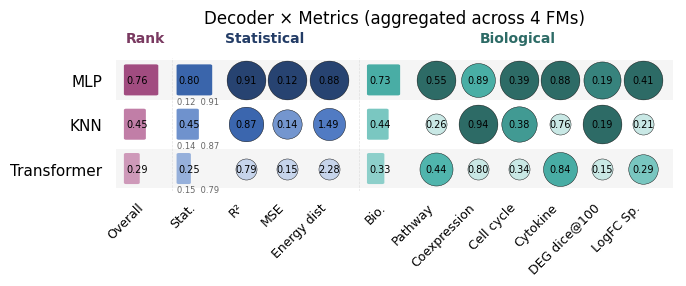

In [8]:
dec_vals = df_all.groupby(["decoder", "metric"])["mean"].mean().unstack()
dec_vals = dec_vals[[m for m in metric_labels if m in dec_vals.columns]]

rank_pcts_dec = pd.DataFrame(index=dec_vals.index)
for col in dec_vals.columns:
    vals = dec_vals[col]
    rank_pcts_dec[col] = _rp_paper(vals, higher_map.get(col, True))

stat_labels_d = [m for m in stat_labels if m in dec_vals.columns]
bio_labels_d = [m for m in bio_labels if m in dec_vals.columns]

hh_dec = (compute_scores_per_replicate(df_all, group_cols=["decoder"])
          .groupby("decoder")[["score_overall", "score_distributional", "score_biological"]].mean())
rank_pcts_dec["stat_rank"]    = hh_dec["score_distributional"]
rank_pcts_dec["bio_rank"]     = hh_dec["score_biological"]
rank_pcts_dec["overall_rank"] = hh_dec["score_overall"]

dec_order = rank_pcts_dec.sort_values("overall_rank", ascending=False).index.tolist()

col_entries_d = []
col_entries_d.append(("Overall", "rank_bar", "overall_rank", "Overall"))
col_entries_d.append(("Stat.", "rank_bar", "stat_rank", "Stat."))
for m in stat_labels_d:
    col_entries_d.append((m, "metric_circle", m, "Stat."))
col_entries_d.append(("Bio.", "rank_bar", "bio_rank", "Bio."))
for m in bio_labels_d:
    col_entries_d.append((m, "metric_circle", m, "Bio."))

col_x_d = []
x = 0.0
spacing = 0.55
gap_small = 0.08
gap_large = 0.25
for i, (name, ctype, key, group) in enumerate(col_entries_d):
    if i == 1:
        x += 0.15
    elif i == 2:
        x += gap_small
    elif ctype == "rank_bar" and key == "bio_rank":
        x += gap_large
    elif i > 0 and col_entries_d[i-1][1] == "rank_bar" and col_entries_d[i-1][3] == "Bio.":
        x += gap_small
    col_x_d.append(x)
    x += spacing

col_x_d = np.array(col_x_d)
n_decs = len(dec_order)

fig, ax = plt.subplots(figsize=(7, 3))

for i in range(n_decs):
    if i % 2 == 0:
        ax.add_patch(Rectangle(
            (col_x_d[0] - 0.40, i - 0.45), col_x_d[-1] - col_x_d[0] + 0.80, 0.9,
            fc="#f5f5f5", ec="none", zorder=0
        ))

for i, dec in enumerate(dec_order):
    y = i
    for j, (name, ctype, key, group) in enumerate(col_entries_d):
        if ctype == "rank_bar":
            val = rank_pcts_dec.loc[dec, key]
            cell_left = col_x_d[j] - 0.26
            bar_w = val * 0.52
            rc = RANK_COLORS[group]
            hh, ll, ss = hex_to_hls(rc)
            bar_color = hls_to_hex(hh, 0.35 + 0.5*(1-val), ss)
            rect = FancyBboxPatch(
                (cell_left, y - 0.32), bar_w, 0.64,
                boxstyle="round,pad=0.03", fc=bar_color, ec="none", zorder=2
            )
            ax.add_patch(rect)
            ax.text(cell_left, y, f"{val:.2f}",
                    ha="left", va="center", fontsize=7, color="black", zorder=3)

            if key == "stat_rank":
                mse_val = dec_vals.loc[dec, "MSE"] if "MSE" in dec_vals.columns else np.nan
                r2_val = dec_vals.loc[dec, "R\u00b2"] if "R\u00b2" in dec_vals.columns else np.nan
                if np.isfinite(mse_val) and np.isfinite(r2_val):
                    ax.text(col_x_d[j], y + 0.38, f"{mse_val:.2f}  {r2_val:.2f}",
                            ha="center", va="top", fontsize=6, color="0.4", zorder=3)

        elif ctype == "metric_circle":
            val = dec_vals.loc[dec, key]
            if np.isnan(val):
                continue
            hib = higher_map.get(key, True)
            col_vals = dec_vals[key]
            bl_val = baseline_means.get(key, np.nan)
            if hib:
                vmin = bl_val if np.isfinite(bl_val) else col_vals.min()
                vmax = col_vals.max()
                score = np.clip((val - vmin) / (vmax - vmin), 0, 1) if vmax > vmin else 0.5
            else:
                vmax = bl_val if np.isfinite(bl_val) else col_vals.max()
                vmin = col_vals.min()
                score = np.clip((vmax - val) / (vmax - vmin), 0, 1) if vmax > vmin else 0.5

            base_c = RANK_COLORS[group]
            hh, ll, ss = hex_to_hls(base_c)
            circle_color = hls_to_hex(hh, 0.85 - 0.55*score, ss)

            size = score * 550 + 230
            ax.scatter(col_x_d[j], y, s=size, c=circle_color, edgecolors="black", linewidths=0.3, zorder=3)
            ax.text(col_x_d[j], y, f"{val:.2f}", ha="center", va="center", fontsize=7,
                    color="black", zorder=4)

col_names_d = [e[0] for e in col_entries_d]
ax.set_yticks(range(n_decs))
ax.set_yticklabels([DECODER_LABELS.get(d, d) for d in dec_order], fontsize=11)
ax.set_xticks(col_x_d)
ax.set_xticklabels(col_names_d, rotation=45, ha="right", fontsize=9)
ax.set_xlim(col_x_d[0] - 0.45, col_x_d[-1] + 0.45)
ax.set_ylim(-0.5, n_decs - 0.5)
ax.invert_yaxis()

sep_after_overall = (col_x_d[0] + col_x_d[1]) / 2
ax.axvline(sep_after_overall, color="0.82", ls="--", lw=0.5, alpha=0.6)
bio_rank_idx = next(j for j, (_, t, k, _) in enumerate(col_entries_d) if t == "rank_bar" and k == "bio_rank")
sep_before_bio = (col_x_d[bio_rank_idx-1] + col_x_d[bio_rank_idx]) / 2
ax.axvline(sep_before_bio, color="0.82", ls="--", lw=0.5, alpha=0.6)

header_y = -0.85
ax.text(col_x_d[0], header_y, "Rank", ha="center", fontsize=10, fontweight="bold", color="#7A3A61")
stat_range = [j for j, (_, _, _, g) in enumerate(col_entries_d) if g == "Stat."]
ax.text(np.mean(col_x_d[stat_range]), header_y, "Statistical", ha="center", fontsize=10, fontweight="bold", color="#233C66")
bio_range = [j for j, (_, _, _, g) in enumerate(col_entries_d) if g == "Bio."]
ax.text(np.mean(col_x_d[bio_range]), header_y, "Biological", ha="center", fontsize=10, fontweight="bold", color="#2D6B66")

for spine in ax.spines.values(): spine.set_visible(False)
ax.grid(False)
ax.tick_params(left=False, bottom=False)
ax.set_title("Decoder \u00d7 Metrics (aggregated across 4 FMs)", pad=25)
plt.tight_layout()
OUT = "../figs/fig3/decoder_dec_funky.svg"
fig.savefig(OUT, format="svg", bbox_inches="tight")
plt.show()

## 7. Panel E — FM × Decoder Full Grid

In [9]:
from dataclasses import dataclass
from typing import Sequence, Mapping, Optional, Union
from scipy import stats as _stats

@dataclass
class ResultItem:
    dataset: str
    split: str
    source: Union[str, pd.DataFrame]
    model_col: Optional[str] = "Unnamed: 0"
    latent: Optional[str] = None


def _load_one(item: ResultItem) -> pd.DataFrame:
    df = pd.read_csv(item.source) if isinstance(item.source, str) else item.source.copy()
    df["_model"]   = df.index.astype(str) if item.model_col is None else df[item.model_col].astype(str)
    df["_dataset"] = item.dataset
    df["_split"]   = item.split
    if item.latent is not None: df["_latent"] = str(item.latent)
    return df


def combine_results(items, *, models, model_rename=None):
    dfs = []
    for it in items:
        d = _load_one(it)
        if model_rename is not None:
            d["_model"] = d["_model"].map(lambda x: model_rename.get(x, x))
        d = d[d["_model"].isin(models)].copy()
        dfs.append(d)
    big = pd.concat(dfs, axis=0, ignore_index=True)
    big["_model"] = pd.Categorical(big["_model"], categories=list(models), ordered=True)
    return big


def to_long(big_df, *, metric_cols=None):
    meta = [c for c in big_df.columns if c.startswith("_")]
    if metric_cols is None:
        metric_cols = [c for c in big_df.columns if c not in meta]
    long = big_df.melt(id_vars=meta, value_vars=list(metric_cols),
                       var_name="metric", value_name="value")
    long["value"] = pd.to_numeric(long["value"], errors="coerce")
    return long


RES_DIR = "../frozen/figs/results"
D_MODELS = ["PCA", "AE", "mlAE", "olAE", "scVI", "nlscVI", "mlscVI"]
LATENTS = [10, 32, 128, 512, 2048]

MODEL_LABELS = {
    "AE":          "AE-None",
    "mlAE":        "AE-Modeled",
    "olAE":        "AE-Observed",
    "nlscVI":      "VAE-None",
    "mlscVI":      "VAE-Modeled",
    "scVI":        "VAE-Observed",
    "PCA":         "PCA",
    "SE":          "SE-2058",
    "scConcept":   "scConcept-512",
    "scGPT":       "scGPT-512",
    "scimilarity": "SCimilarity-128",
}

METRICS = {
    "distributional_r2_score":                  "R\u00b2",
    "rev_distributional_mse":                   "MSE",
    "rev_distributional_energy_distance":       "Energy dist",
    "pathway_spearman_average":                 "Pathway",
    "coexpression_spearman_average":            "Coexpression",
    "cellcycle_proportion_same_phase":          "Cell cycle",
    "deg_wilcoxon_pred_deg_dice_100":           "DEG dice@100",
    "deg_wilcoxon_pred_mean_genediff_spearman": "LogFC Sp.",
    "cytokine_spearman_average":                "Cytokine",
}

items_pbmc = [
    ResultItem(dataset="pbmc", split=s,
               source=f"{RES_DIR}/pbmc_{s}_metrics_summary_latent{j}.csv",
               model_col="Unnamed: 0", latent=str(j))
    for s in ["split01", "split02", "split03"]
    for j in LATENTS
]
big_pbmc  = combine_results(items_pbmc, models=D_MODELS)
df_pbmc = to_long(big_pbmc)

df_pbmc["metric"] = df_pbmc.metric.map(METRICS)
df_pbmc["_model"] = df_pbmc._model.map(MODEL_LABELS)
df_pbmc = df_pbmc[~df_pbmc.metric.isna()].copy()

df_pbmc["model"] = df_pbmc.apply(lambda x: x._model + "-" + x._latent, axis=1)
df_pbmc["decoder"] = df_pbmc._model
df_pbmc["split"] = df_pbmc._split
df_pbmc["mean"] = df_pbmc.value

df_pbmc.loc[df_pbmc.metric=="MSE", "mean"] *= -1
df_pbmc.loc[df_pbmc.metric=="Energy dist", "mean"] *= -1

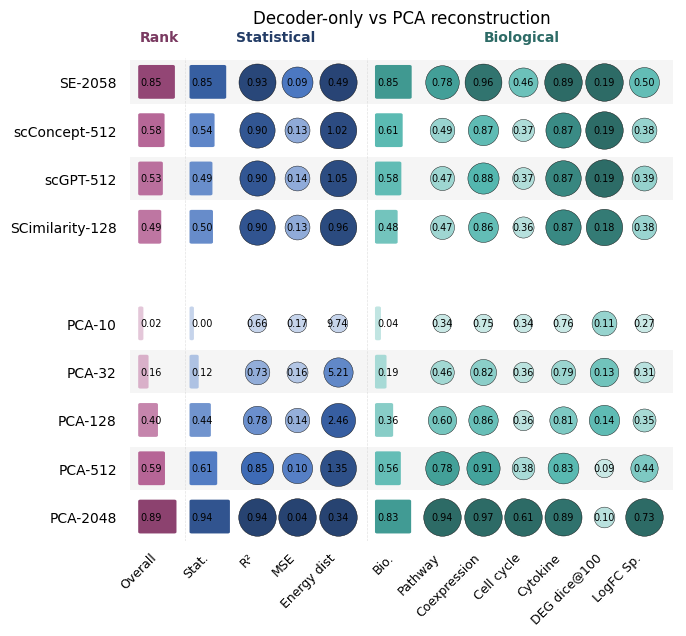

In [10]:
df_pca = df_pbmc[df_pbmc.decoder == "PCA"]

df_combined = pd.concat([df_mlp, df_pca], ignore_index=True)

combined_vals = df_combined.groupby(["model", "metric"])["mean"].mean().unstack()
combined_vals = combined_vals[[m for m in metric_labels if m in combined_vals.columns]]

def bootstrap_ci_sp(values, n_boot=4000, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    values = np.array(values, dtype=float)
    values = values[~np.isnan(values)]
    if len(values) == 0:
        return np.nan, np.nan, np.nan
    if len(values) == 1:
        v = float(values[0]); return v, v, v
    boots = [np.mean(rng.choice(values, size=len(values), replace=True)) for _ in range(n_boot)]
    return float(np.mean(boots) - np.quantile(boots, alpha/2)), float(np.quantile(boots, 1-alpha/2) - np.mean(boots))

rank_pcts_c = pd.DataFrame(index=combined_vals.index)
for col in combined_vals.columns:
    vals = combined_vals[col]
    rank_pcts_c[col] = _rp_paper(vals, higher_map.get(col, True))

stat_labels_c = [m for m in stat_labels if m in combined_vals.columns]
bio_labels_c = [m for m in bio_labels if m in combined_vals.columns]

df_pca_hh = df_pca.copy()
df_pca_hh["higher_better"] = df_pca_hh["metric"].map(higher_map).fillna(True)
df_joint_hh = pd.concat([df_mlp, df_pca_hh], ignore_index=True)
hh = (compute_scores_per_replicate(df_joint_hh, group_cols=["model"])
      .groupby("model")[["score_overall", "score_distributional", "score_biological"]].mean())
rank_pcts_c["stat_rank"]    = hh["score_distributional"]
rank_pcts_c["bio_rank"]     = hh["score_biological"]
rank_pcts_c["overall_rank"] = hh["score_overall"]
rank_pcts_c[["rank_low_diff", "rank_high_diff"]] = rank_pcts_c[metric_labels].apply(bootstrap_ci_sp, axis=1, result_type="expand")

is_fm = ~combined_vals.index.str.startswith("PCA-")
fm_order = rank_pcts_c[is_fm].sort_values("overall_rank", ascending=False).index.tolist()
pca_order = [f"PCA-{l}" for l in LATENTS]
combined_order = fm_order + [""] + pca_order

# Column layout
col_entries_c = []
col_entries_c.append(("Overall", "rank_bar", "overall_rank", "Overall"))
col_entries_c.append(("Stat.", "rank_bar", "stat_rank", "Stat."))
for m in stat_labels_c:
    col_entries_c.append((m, "metric_circle", m, "Stat."))
col_entries_c.append(("Bio.", "rank_bar", "bio_rank", "Bio."))
for m in bio_labels_c:
    col_entries_c.append((m, "metric_circle", m, "Bio."))

col_x_c = []
x = 0.0
spacing = 0.55
for i, (name, ctype, key, group) in enumerate(col_entries_c):
    if i == 1:
        x += 0.15
    elif i == 2:
        x += 0.08
    elif ctype == "rank_bar" and key == "bio_rank":
        x += 0.25
    elif i > 0 and col_entries_c[i-1][1] == "rank_bar" and col_entries_c[i-1][3] == "Bio.":
        x += 0.08
    col_x_c.append(x)
    x += spacing
col_x_c = np.array(col_x_c)

n_rows = len(combined_order)

fig, ax = plt.subplots(figsize=(7, 6.5))

for i, model in enumerate(combined_order):
    if model == "":
        continue
    if i % 2 == 0:
        ax.add_patch(Rectangle(
            (col_x_c[0] - 0.40, i - 0.45), col_x_c[-1] - col_x_c[0] + 0.80, 0.9,
            fc="#f5f5f5", ec="none", zorder=0
        ))

for i, model in enumerate(combined_order):
    if model == "":
        continue
    y = i
    for j, (name, ctype, key, group) in enumerate(col_entries_c):
        if ctype == "rank_bar":
            val = rank_pcts_c.loc[model, key]
            cell_left = col_x_c[j] - 0.26
            bar_w = val * 0.52
            rc = RANK_COLORS[group]
            hh, ll, ss = hex_to_hls(rc)
            bar_color = hls_to_hex(hh, 0.35 + 0.5*(1-val), ss)
            rect = FancyBboxPatch(
                (cell_left, y - 0.32), bar_w, 0.64,
                boxstyle="round,pad=0.03", fc=bar_color, ec="none", zorder=2
            )
            ax.add_patch(rect)
            ax.text(cell_left, y, f"{val:.2f}",
                    ha="left", va="center", fontsize=7,  color="black", zorder=3)

        elif ctype == "metric_circle":
            val = combined_vals.loc[model, key]
            if np.isnan(val):
                continue
            hib = higher_map.get(key, True)
            col_vals = combined_vals[key]
            bl_val = baseline_means.get(key, np.nan)
            if hib:
                vmin = bl_val if np.isfinite(bl_val) else col_vals.min()
                vmax = col_vals.max()
                score = np.clip((val - vmin) / (vmax - vmin), 0, 1) if vmax > vmin else 0.5
            else:
                vmax = bl_val if np.isfinite(bl_val) else col_vals.max()
                vmin = col_vals.min()
                score = np.clip((vmax - val) / (vmax - vmin), 0, 1) if vmax > vmin else 0.5

            base_c = RANK_COLORS[group]
            hh, ll, ss = hex_to_hls(base_c)
            circle_color = hls_to_hex(hh, 0.85 - 0.55*score, ss)

            size = score * 550 + 180
            ax.scatter(col_x_c[j], y, s=size, c=circle_color, edgecolors="black", linewidths=0.3, zorder=3)
            ax.text(col_x_c[j], y, f"{val:.2f}", ha="center", va="center", fontsize=7, 
                    color="black", zorder=4)

ax.set_yticks(range(n_rows))
ax.set_yticklabels([MODEL_LABELS.get(m, m) for m in combined_order], fontsize=10)
col_names_c = [e[0] for e in col_entries_c]
ax.set_xticks(col_x_c)
ax.set_xticklabels(col_names_c, rotation=45, ha="right", fontsize=9)
ax.set_xlim(col_x_c[0] - 0.45, col_x_c[-1] + 0.45)
ax.set_ylim(-0.5, n_rows - 0.5)
ax.invert_yaxis()

sep_after_overall = (col_x_c[0] + col_x_c[1]) / 2
ax.axvline(sep_after_overall, color="0.82", ls="--", lw=0.5, alpha=0.6)
bio_rank_idx = next(j for j, (_, t, k, _) in enumerate(col_entries_c) if t == "rank_bar" and k == "bio_rank")
sep_before_bio = (col_x_c[bio_rank_idx-1] + col_x_c[bio_rank_idx]) / 2
ax.axvline(sep_before_bio, color="0.82", ls="--", lw=0.5, alpha=0.6)

header_y = -0.85
ax.text(col_x_c[0], header_y, "Rank", ha="center", fontsize=10, fontweight="bold", color="#7A3A61")
stat_range = [j for j, (_, _, _, g) in enumerate(col_entries_c) if g == "Stat."]
ax.text(np.mean(col_x_c[stat_range]), header_y, "Statistical", ha="center", fontsize=10, fontweight="bold", color="#233C66")
bio_range = [j for j, (_, _, _, g) in enumerate(col_entries_c) if g == "Bio."]
ax.text(np.mean(col_x_c[bio_range]), header_y, "Biological", ha="center", fontsize=10, fontweight="bold", color="#2D6B66")

for spine in ax.spines.values(): spine.set_visible(False)
ax.grid(False)
ax.tick_params(left=False, bottom=False)
ax.set_title("Decoder-only vs PCA reconstruction", pad=25)
plt.tight_layout()
OUT = "../figs/fig3/decoder_vs_pca_funky.svg"
fig.savefig(OUT, format="svg", bbox_inches="tight")
plt.show()

<Figure size 720x420 with 0 Axes>

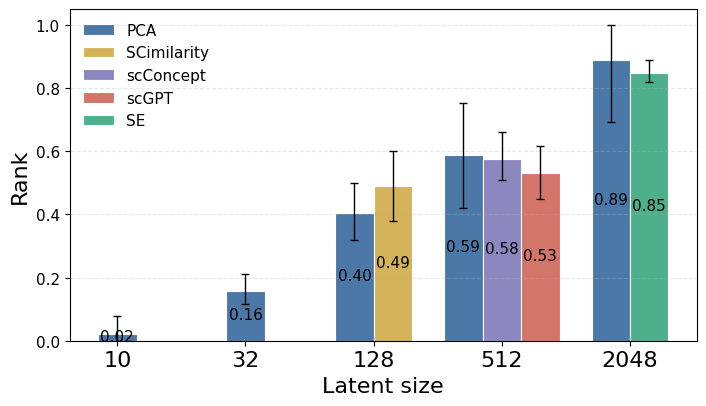

In [11]:
fig = plt.figure(figsize=(7.2, 4.2))

tmp = rank_pcts_c[["overall_rank", "rank_low_diff", "rank_high_diff"]].copy()
tmp["labels"] = [MODEL_LABELS.get(m, m) for m in tmp.index]
tmp["colors"] = [MODEL_COLORS.get(m, "#4C78A8") for m in tmp.index]
tmp["latent"] = tmp.labels.apply(lambda x: int(x.split("-")[1]))
tmp["model"] = tmp.labels.apply(lambda x: x.split("-")[0])
tmp.loc[tmp.model == "SE", "latent"] = 2048

models = sorted(tmp["model"].unique())
latents = sorted(tmp["latent"].unique())

x = np.arange(len(latents))
max_models = len(models)

legends = []
fig = plt.figure(figsize=(7.2, 4.2))
for i_lat, lat in enumerate(latents):
    sub = tmp[tmp["latent"] == lat]
    sub = sub.set_index("model").reindex(models)
    sub.sort_values(["model"], ascending=True, inplace=True)
    present = sub["overall_rank"].notna()
    n = int(present.sum())
    if n == 0:
        continue
    bar_w = 0.3
    offsets = (np.arange(n) - (n - 1) / 2) * bar_w
    for j, (model, row) in enumerate(sub[present].iterrows()):
        color = row["colors"]
        label = model
        y = row["overall_rank"]
        x_pos = x[i_lat] + offsets[j]
        if label in legends:
            plt.bar(x_pos, y, width=bar_w, color=color, edgecolor="white", linewidth=0.8)
        else:
            plt.bar(x_pos, y, width=bar_w, color=color, edgecolor="white", linewidth=0.8, label=label)
            legends.append(label)
        plt.text(x_pos, y / 2 - 0.02, f"{y:.2f}", ha="center", va="bottom", fontsize=11)

        yerr = [[row["rank_low_diff"]], [row["rank_high_diff"]]]
        plt.errorbar(x_pos, y, yerr=yerr, fmt="none", ecolor="black", elinewidth=1, capsize=3)

plt.xticks(x, latents, fontsize=16)
plt.xlabel("Latent size", fontsize=16)
plt.ylabel("Rank", fontsize=16)
plt.ylim(0, 1.05)
plt.grid(axis="y", ls="--", alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

OUT = "../figs/fig3/decoder_pca_ranking.svg"
fig.savefig(OUT, format="svg", bbox_inches="tight")

## 8. Decoder Full Grid

In [12]:
DATASETS = ["pbmc", "tahoe", "luca"]

items = [
    ResultItem(dataset=d, split=s,
               source=f"{RES_DIR}/{d}_{s}_metrics_summary_latent{j}.csv",
               model_col="Unnamed: 0", latent=str(j))
    for s in ["split01", "split02", "split03"]
    for j in LATENTS
    for d in DATASETS
]
big_all  = combine_results(items, models=D_MODELS)
df_all = to_long(big_all)

df_all["metric"] = df_all.metric.map(METRICS)
df_all["_model"] = df_all._model.map(MODEL_LABELS)
df_all = df_all[~df_all.metric.isna()].copy()

df_all["model"] = df_all.apply(lambda x: x._model + "-" + x._latent, axis=1)
df_all["decoder"] = df_all._model
df_all["split"] = df_all._split
df_all["mean"] = df_all.value
df_all["dataset"] = df_all._dataset

df_all.loc[df_all.metric=="MSE", "mean"] *= -1
df_all.loc[df_all.metric=="Energy dist", "mean"] *= -1

In [13]:
RANK_COLORS = {"Overall": "#7A3A61", "Stat.": "#233C66", "Bio.": "#2D6B66", "Datasets": "#B88A2D"}
DATASET_LABEL = {"tahoe": "Tahoe-100M", "pbmc": "PBMC-10M", "luca": "LuCA"}

combined_vals = df_all.groupby(["model", "metric"])["mean"].mean().unstack()
combined_vals = combined_vals[[m for m in metric_labels if m in combined_vals.columns]]

rank_pcts_c = pd.DataFrame(index=combined_vals.index)
for col in combined_vals.columns:
    vals = combined_vals[col]
    rank_pcts_c[col] = _rp_paper(vals, higher_map.get(col, True))

stat_labels_c = [m for m in stat_labels if m in combined_vals.columns]
bio_labels_c = [m for m in bio_labels if m in combined_vals.columns]

df_global = df_all.copy()
df_global["higher_better"] = df_global["metric"].map(higher_map).fillna(True)
df_global["split"] = df_global["dataset"].astype(str) + "__" + df_global["split"].astype(str)
hh_global = (compute_scores_per_replicate(df_global, group_cols=["model"])
             .groupby("model")[["score_overall", "score_distributional", "score_biological"]].mean())
rank_pcts_c["stat_rank"]    = hh_global["score_distributional"]
rank_pcts_c["bio_rank"]     = hh_global["score_biological"]
rank_pcts_c["overall_rank"] = hh_global["score_overall"]

for dataset in DATASETS:
    df_ds = df_all[df_all.dataset == dataset].copy()
    df_ds["higher_better"] = df_ds["metric"].map(higher_map).fillna(True)
    hh_ds = (compute_scores_per_replicate(df_ds, group_cols=["model"])
             .groupby("model")["score_overall"].mean())
    rank_pcts_c[f"overall_rank_{dataset}"] = hh_ds

model_order = rank_pcts_c.sort_values("overall_rank", ascending=False).index.tolist()

col_entries_c = []
col_entries_c.append(("Overall", "rank_bar", "overall_rank", "Overall"))
for dataset in DATASETS:
    col_entries_c.append((DATASET_LABEL[dataset], "dataset_circle", f"overall_rank_{dataset}", "Datasets"))
col_entries_c.append(("Stat.", "rank_bar", "stat_rank", "Stat."))
for m in stat_labels_c:
    col_entries_c.append((m, "metric_circle", m, "Stat."))
col_entries_c.append(("Bio.", "rank_bar", "bio_rank", "Bio."))
for m in bio_labels_c:
    col_entries_c.append((m, "metric_circle", m, "Bio."))

col_x_c = []
x = 0.0
spacing = 0.55
for i, (name, ctype, key, group) in enumerate(col_entries_c):
    if i == 1:
        x += 0.15
    elif ctype == "rank_bar" and key == "stat_rank":
        x += 0.25
    elif ctype == "rank_bar" and key == "bio_rank":
        x += 0.25
    elif i > 0 and col_entries_c[i-1][1] == "rank_bar" and col_entries_c[i-1][3] in ["Bio.", "Stat."]:
        x += 0.08
    col_x_c.append(x)
    x += spacing
col_x_c = np.array(col_x_c)

n_rows = len(model_order)

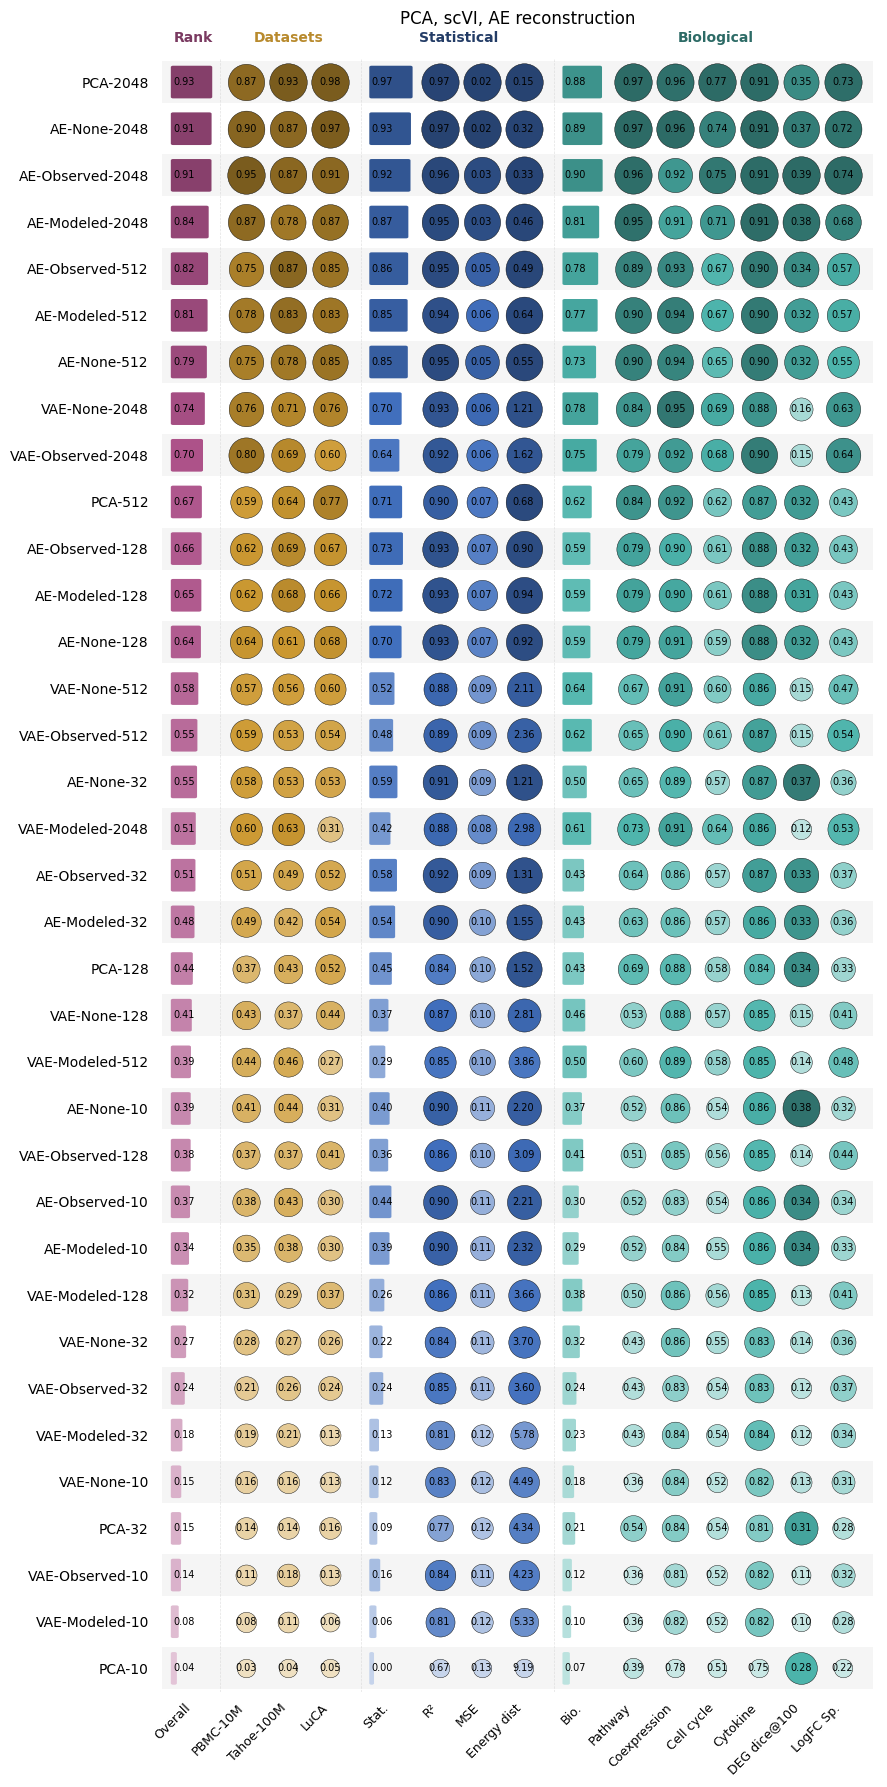

In [14]:
fig, ax = plt.subplots(figsize=(9, 18))

for i, model in enumerate(model_order):
    if model == "":
        continue
    if i % 2 == 0:
        ax.add_patch(Rectangle(
            (col_x_c[0] - 0.40, i - 0.45), col_x_c[-1] - col_x_c[0] + 0.80, 0.9,
            fc="#f5f5f5", ec="none", zorder=0
        ))

for i, model in enumerate(model_order):
    if model == "":
        continue
    y = i
    for j, (name, ctype, key, group) in enumerate(col_entries_c):
        if ctype == "rank_bar":
            val = rank_pcts_c.loc[model, key]
            cell_left = col_x_c[j] - 0.26
            bar_w = val * 0.52
            rc = RANK_COLORS[group]
            hh, ll, ss = hex_to_hls(rc)
            bar_color = hls_to_hex(hh, 0.35 + 0.5*(1-val), ss)
            rect = FancyBboxPatch(
                (cell_left, y - 0.32), bar_w, 0.64,
                boxstyle="round,pad=0.03", fc=bar_color, ec="none", zorder=2
            )
            ax.add_patch(rect)
            ax.text(cell_left, y, f"{val:.2f}",
                    ha="left", va="center", fontsize=7,  color="black", zorder=3)

        elif ctype == "metric_circle":
            val = combined_vals.loc[model, key]
            if np.isnan(val):
                continue
            hib = higher_map.get(key, True)
            col_vals = combined_vals[key]
            bl_val = baseline_means.get(key, np.nan)
            if hib:
                vmin = bl_val if np.isfinite(bl_val) else col_vals.min()
                vmax = col_vals.max()
                score = np.clip((val - vmin) / (vmax - vmin), 0, 1) if vmax > vmin else 0.5
            else:
                vmax = bl_val if np.isfinite(bl_val) else col_vals.max()
                vmin = col_vals.min()
                score = np.clip((vmax - val) / (vmax - vmin), 0, 1) if vmax > vmin else 0.5

            base_c = RANK_COLORS[group]
            hh, ll, ss = hex_to_hls(base_c)
            circle_color = hls_to_hex(hh, 0.85 - 0.55*score, ss)
            
            size = score * 550 + 180
            ax.scatter(col_x_c[j], y, s=size, c=circle_color, edgecolors="black", linewidths=0.3, zorder=3)
            ax.text(col_x_c[j], y, f"{val:.2f}", ha="center", va="center", fontsize=7, 
                    color="black", zorder=4)
        
        elif ctype == "dataset_circle":
            val = rank_pcts_c.loc[model, key]
            if np.isnan(val):
                continue
            hib = higher_map.get(key, True)
            col_vals = rank_pcts_c[key]
            vmin = col_vals.min()
            vmax = col_vals.max()
            score = np.clip((val - vmin) / (vmax - vmin), 0, 1) if vmax > vmin else 0.5

            base_c = RANK_COLORS[group]
            hh, ll, ss = hex_to_hls(base_c)
            circle_color = hls_to_hex(hh, 0.85 - 0.55*score, ss)

            size = score * 550 + 180
            ax.scatter(col_x_c[j], y, s=size, c=circle_color, edgecolors="black", linewidths=0.3, zorder=3)
            ax.text(col_x_c[j], y, f"{val:.2f}", ha="center", va="center", fontsize=7, 
                    color="black", zorder=4)

ax.set_yticks(range(n_rows))
ax.set_yticklabels([m for m in model_order], fontsize=10)
col_names_c = [e[0] for e in col_entries_c]
ax.set_xticks(col_x_c)
ax.set_xticklabels(col_names_c, rotation=45, ha="right", fontsize=9)
ax.set_xlim(col_x_c[0] - 0.45, col_x_c[-1] + 0.45)
ax.set_ylim(-0.5, n_rows - 0.5)
ax.invert_yaxis()

sep_after_overall = (col_x_c[0] + col_x_c[1]) / 2
ax.axvline(sep_after_overall, color="0.82", ls="--", lw=0.5, alpha=0.6)
stat_rank_idx = next(j for j, (_, t, k, _) in enumerate(col_entries_c) if t == "rank_bar" and k == "stat_rank")
sep_before_stat = (col_x_c[stat_rank_idx-1] + col_x_c[stat_rank_idx]) / 2
ax.axvline(sep_before_stat, color="0.82", ls="--", lw=0.5, alpha=0.6)
bio_rank_idx = next(j for j, (_, t, k, _) in enumerate(col_entries_c) if t == "rank_bar" and k == "bio_rank")
sep_before_bio = (col_x_c[bio_rank_idx-1] + col_x_c[bio_rank_idx]) / 2
ax.axvline(sep_before_bio, color="0.82", ls="--", lw=0.5, alpha=0.6)

header_y = -0.85
ax.text(col_x_c[0], header_y, "Rank", ha="center", fontsize=10, fontweight="bold", color="#7A3A61")
dataset_range = [j for j, (_, _, _, g) in enumerate(col_entries_c) if g == "Datasets"]
ax.text(np.mean(col_x_c[dataset_range]), header_y, "Datasets", ha="center", fontsize=10, fontweight="bold", color="#B88A2D")
stat_range = [j for j, (_, _, _, g) in enumerate(col_entries_c) if g == "Stat."]
ax.text(np.mean(col_x_c[stat_range]), header_y, "Statistical", ha="center", fontsize=10, fontweight="bold", color="#233C66")
bio_range = [j for j, (_, _, _, g) in enumerate(col_entries_c) if g == "Bio."]
ax.text(np.mean(col_x_c[bio_range]), header_y, "Biological", ha="center", fontsize=10, fontweight="bold", color="#2D6B66")

for spine in ax.spines.values(): spine.set_visible(False)
ax.grid(False)
ax.tick_params(left=False, bottom=False)
ax.set_title("PCA, scVI, AE reconstruction", pad=25)
plt.tight_layout()
OUT = "../figs/fig3/reconstruction_funky.svg"
fig.savefig(OUT, format="svg", bbox_inches="tight")
plt.show()

## 9. Decoder Architecture and KNN

In [15]:
DECODER_CONFIGS_KNN = {
    "MLP": None,
    "KNN_5": "KNN_5",
    "KNN_10": "KNN_10",
    "KNN_20": "KNN_20",
    "KNN_50": "KNN_50",
    "Transformer": "500_TF128_H8_L6_*",
}

DECODER_COLORS_KNN = {
    "MLP": "#6baed6",        # soft blue
    "KNN_10": "#d4956a",     # muted peach
    "KNN_5": "#2f4f4f",
    "KNN_20": "#f5deb3",
    "KNN_50": "#b22222",
    "Transformer": "#8fbc8f", # sage green
}

DECODER_LABELS_KNN = {
    "MLP":         "MLP",
    "KNN_5":      "KNN-5",
    "KNN_10":      "KNN-10",
    "KNN_20":      "KNN-20",
    "KNN_50":      "KNN-50",
    "Transformer": "Transformer",
}

df_all = pd.read_csv("../frozen/figs/decoder_only_knns.csv")

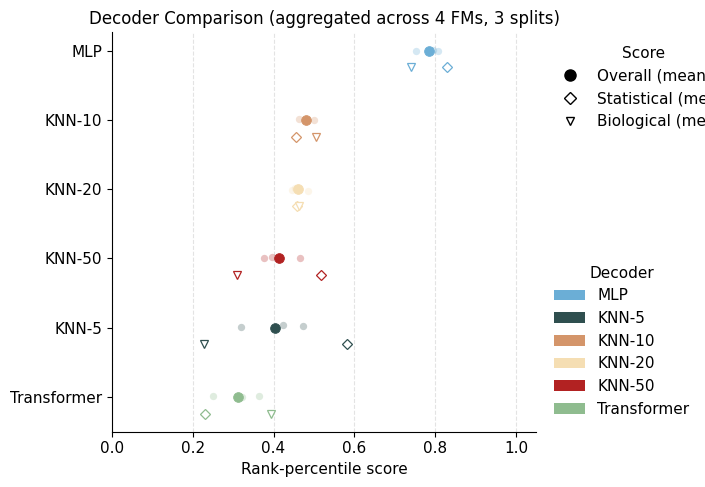

In [16]:
score_dec = compute_scores_per_replicate(df_all, group_cols=["decoder"])
agg_dec = make_agg_df(score_dec, group_cols=["decoder"])

order_df = agg_dec[agg_dec["score"] == "score_overall"].sort_values("mean", ascending=False)
dec_order = order_df["decoder"].tolist()

fig, ax = plt.subplots(figsize=(10, 5))
ypos = np.arange(len(dec_order)).astype(float)

rng = np.random.default_rng(0)
for i, dec in enumerate(dec_order):
    reps = score_dec[score_dec["decoder"] == dec]
    col = DECODER_COLORS_KNN.get(dec, "gray")
    xs = reps["score_overall"].to_numpy(dtype=float)
    jitter = rng.normal(0, 0.015, size=len(xs))
    ax.scatter(xs, np.full_like(xs, ypos[i]) + jitter, s=28, color=col, alpha=0.28, linewidths=0, zorder=1)

for i, dec in enumerate(dec_order):
    col = DECODER_COLORS_KNN.get(dec, "gray")
    row_o = agg_dec[(agg_dec["decoder"] == dec) & (agg_dec["score"] == "score_overall")]
    if not row_o.empty:
        mean, lo, hi = float(row_o["mean"].iloc[0]), float(row_o["lo"].iloc[0]), float(row_o["hi"].iloc[0])
        ax.plot(mean, ypos[i], "o", ms=7, color=col, mec=col, mew=0.6, zorder=6)
    row_d = agg_dec[(agg_dec["decoder"] == dec) & (agg_dec["score"] == "score_distributional")]
    if not row_d.empty:
        ax.plot(float(row_d["mean"].iloc[0]), ypos[i] + 0.24, marker="D", ms=5.5,
                mfc="white", mec=col, mew=0.9, ls="None", zorder=7)
    row_b = agg_dec[(agg_dec["decoder"] == dec) & (agg_dec["score"] == "score_biological")]
    if not row_b.empty:
        ax.plot(float(row_b["mean"].iloc[0]), ypos[i] + 0.24, marker="v", ms=5.5,
                mfc="white", mec=col, mew=0.9, ls="None", zorder=7)

ax.set_yticks(ypos)
ax.set_yticklabels([DECODER_LABELS_KNN.get(d, d) for d in dec_order])
ax.invert_yaxis()
ax.set_xlim(0, 1.05)
ax.set_xlabel("Rank-percentile score")
ax.xaxis.grid(True, ls="--", alpha=0.35)
ax.set_axisbelow(True)
for spine in ["top", "right"]: ax.spines[spine].set_visible(False)

fig.subplots_adjust(right=0.72)
score_handles = [
    Line2D([0],[0], marker="o", color="black", ls="None", ms=8, label="Overall (mean)"),
    Line2D([0],[0], marker="D", color="black", ls="None", mfc="white", mew=1.0, ms=6, label="Statistical (mean)"),
    Line2D([0],[0], marker="v", color="black", ls="None", mfc="white", mew=1.0, ms=6, label="Biological (mean)"),
]
leg1 = ax.legend(handles=score_handles, title="Score", loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False)
dec_handles = [Patch(facecolor=DECODER_COLORS_KNN[d], edgecolor="none", label=DECODER_LABELS_KNN.get(d, d)) for d in DECODER_CONFIGS_KNN]
leg2 = ax.legend(handles=dec_handles, title="Decoder", loc="upper left", bbox_to_anchor=(1.01, 0.45), frameon=False)
ax.add_artist(leg1)
ax.set_title("Decoder Comparison (aggregated across 4 FMs, 3 splits)")
plt.tight_layout(rect=[0, 0, 0.72, 1])
OUT_SVG = "../figs/fig3/decoder_knn_comparison.svg"
fig.savefig(OUT_SVG, format="svg", bbox_inches="tight", bbox_extra_artists=[leg1, leg2])
plt.show()

## Panel F — Foundation model embedding UMAP

1% sample from all three splits (train + val + test).  
UMAP computed **per embedding space** (not on gene expression).  
Grid: rows = cell type / donor / cytokine &nbsp;|&nbsp; columns = SE, scGPT, scConcept, scimilarity.

In [17]:
with open("../frozen/panelf_umaps.pkl", "rb") as f:
    UMAPS_F = pickle.load(f)
    f.close()

with open("../frozen/panelf_obs.pkl", "rb") as f:
    all_obs = pickle.load(f)
    f.close()

EMB_MODELS = ['SE', 'scGPT', 'scConcept', 'scimilarity']
EMB_KEYS   = {m: f'X_{m}' for m in EMB_MODELS}

COL_CELLTYPE = 'cell_type'
COL_DONOR    = 'donor'
COL_CYTOKINE = 'target_gene'

In [18]:
def _palette(vals, cmap_name='tab20'):
    cats = sorted(pd.Series(vals).dropna().unique())
    cm = ["#4C78A8", "#F58518", "#E45756", "#72B7B2", "#54A24B", "#EECA3B", "#B279A2", "#FF9DA6", "#9D755D", "#BAB0AC", "#439894", "#83BCE6", "#D67195", "#B5CF6B", "#FABFD2", "#B6992D", "#499894", "#86BCB6", "#D6A5C9", "#D3D3D3"]
    return {c: cm[i] for i, c in enumerate(cats)}

CT_PAL = _palette(all_obs[COL_CELLTYPE], 'tab10')    if COL_CELLTYPE else {}

COLORINGS_F = [
    (COL_CELLTYPE, CT_PAL, 'Cell type',  30),
]

print(f'Cell types : {len(CT_PAL)}')

Cell types : 16


Saved → ../figs/fig3/decoder_panelF_emb_umap.svg


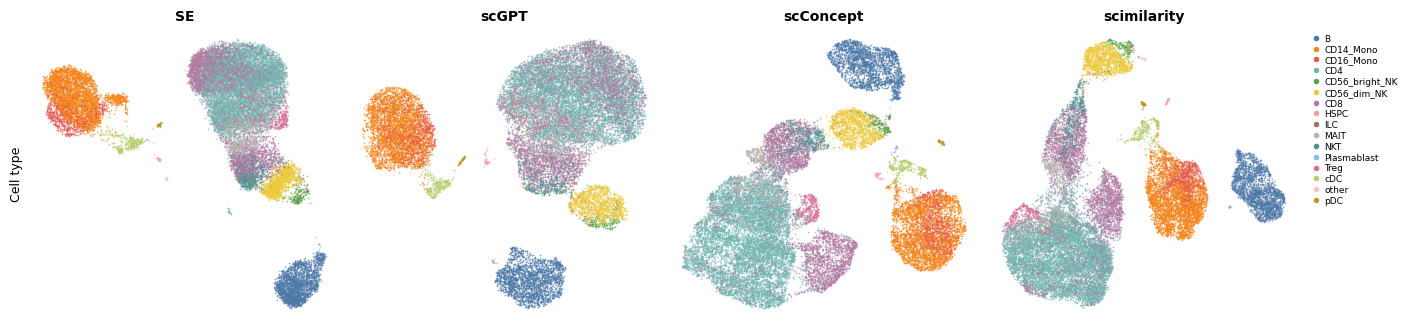

In [19]:
import os
models_present = [m for m in EMB_MODELS if m in UMAPS_F]
n_rows = len(COLORINGS_F)
n_cols = len(models_present)

PT_S = 1.5
PT_A = 0.65

fig_F, axes_F = plt.subplots(
    n_rows, n_cols,
    figsize=(3.5 * n_cols, 3.2 * n_rows),
    constrained_layout=True,
)

if n_rows == 1:   axes_F = axes_F[np.newaxis, :]
if n_cols == 1:   axes_F = axes_F[:, np.newaxis]

for col_i, model in enumerate(models_present):
    tmp = UMAPS_F[model]
    xy  = tmp.obsm['X_umap']

    for row_i, (obs_col, palette, row_label, max_leg) in enumerate(COLORINGS_F):
        ax = axes_F[row_i, col_i]

        if obs_col is None or obs_col not in tmp.obs.columns:
            ax.axis('off')
            ax.text(0.5, 0.5, f'{obs_col!r}\nnot found',
                    ha='center', va='center', transform=ax.transAxes, fontsize=8)
            continue

        vals = tmp.obs[obs_col].astype(str).values
        categories = sorted(set(vals))

        for cat in categories:
            mask = vals == cat
            ax.scatter(xy[mask, 0], xy[mask, 1],
                       s=PT_S, alpha=PT_A,
                       color=palette.get(cat, '0.6'),
                       linewidths=0, rasterized=True)

        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values(): sp.set_visible(False)

        if row_i == 0:
            ax.set_title(model, fontsize=10, fontweight='bold', pad=4)

        if col_i == 0:
            ax.set_ylabel(row_label, fontsize=9, labelpad=4)

        if col_i == n_cols - 1 and len(categories) <= max_leg:
            handles = [
                Line2D([0],[0], marker='o', color='w',
                       markerfacecolor=palette.get(c, '0.6'),
                       markersize=5, linewidth=0, label=c)
                for c in categories
            ]
            ncol = 1 + len(handles) // 25
            ax.legend(
                handles=handles,
                bbox_to_anchor=(1.02, 1), loc='upper left',
                fontsize=6.5, frameon=False, ncol=ncol,
                handlelength=0.4, labelspacing=0.2, columnspacing=0.5,
            )

svg_F = '../figs/fig3/decoder_panelF_emb_umap.svg'
fig_F.savefig(svg_F, bbox_inches='tight', dpi=300)
print(f'Saved → {svg_F}')
plt.show()